In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

### Scenario A — App Review Analysis: A product team analyzes their app's reviews on the App Store to understand user satisfaction. The average rating is 4.3/5, so they conclude that most users are happy. They plan to reduce investment in customer support.

In the first Scenario A : We use in app micro-surveys triggered at random intervals to capture a representative slice of the active user base. App Review Analysis Bias Type: Self-Selection Bias

### Scenario B — Startup Success Study: A business school studies 200 successful tech startups (all founded in the last 10 years and still operating) to identify common traits that predict startup success. They find that 80% had a pivot in their first two years and conclude that pivoting is a key success strategy.

In the second Scenario B : We include "deceased" or failed startups in the dataset to see if the pivot rate differs between winners and loosers.Survivorship Bias

### Scenario C — Health Survey: A health organization sends a voluntary online survey to 50,000 email subscribers asking about exercise habits and health outcomes. The survey receives 5,000 responses (10% response rate). Results show that respondents exercise an average of 5 hours per week and have excellent self-reported health.

This suffers from Non-Response Bias. With only 10% response rate,it's likely that people who are health-conscious were more motivated to complete the survey. We should implement follow-up outreach to non-respondesnts or specific geographic tiers rather than using a GLOBAL average.

### Scenario D — Salary Benchmarking: A recruiting platform publishes average salaries by job title based on user-submitted salary data. The platform is popular among tech workers in large cities. A company in a small town uses this data to set their salary bands.

This is Sampling Bias(specifically, geographic and industry skew). Tech workers in large cities have a significantly different cost of living than workers in small cities/towns. We should filter the benchmarking data by "Cost of living" indices or specific geographic tiers rather than using a global average.

True Mean Age: 40.02
True Mean Income: 80040.74
True Mean Satisfaction: 3.28
Region Proportions: {'Urban': 0.59927, 'Suburban': 0.25075, 'Rural': 0.14998}


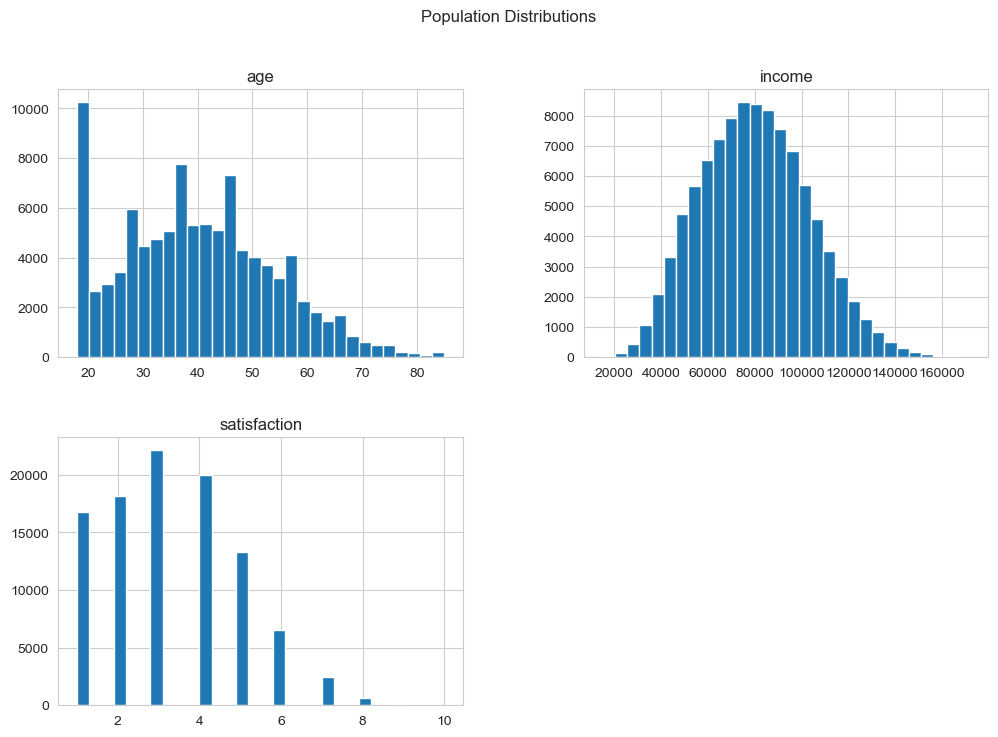

In [3]:

n = 100000
age = np.random.normal(40, 15, n).astype(int)
age = np.clip(age, 18, 85)
income = (1500 * age) + np.random.normal(20000, 10000,n)
income = np.clip(income, 15000, 250000)
satisfaction = (income / 25000) + np.random.normal(0, 1.5, n)
satisfaction = np.round(satisfaction).astype(int)
satisfaction = np.clip(satisfaction, 1, 10)
regions = ["Urban", "Suburban", "Rural"]
region = np.random.choice(regions, size=n, p=[0.60, 0.25, 0.15])
df_pop = pd.DataFrame({
    'age': age,
    'income': income,
    'satisfaction': satisfaction,
    'region': region
})
true_means = {
    'mean_age': df_pop['age'].mean(),
    'mean_income': df_pop['income'].mean(),
    'mean_satisfaction': df_pop['satisfaction'].mean(),
    'region_proportions': df_pop['region'].value_counts(normalize=True).to_dict()
}
print(f"True Mean Age: {true_means['mean_age']:.2f}")
print(f"True Mean Income: {true_means['mean_income']:.2f}")
print(f"True Mean Satisfaction: {true_means['mean_satisfaction']:.2f}")
print("Region Proportions:", true_means['region_proportions'])

df_pop.hist(bins=30, figsize=(12, 8))
plt.suptitle("Population Distributions")
plt.show()

In [4]:
random_sample = df_pop.sample(200)
urban_sample = df_pop[df_pop['region'] == 'Urban'].sample(200)
high_income_sample = df_pop[df_pop['income'] > (df_pop['income'].median())].sample(200)
comparison_df = pd.DataFrame({
    'Metric': ['Mean Age', 'Mean Income', 'Mean Satisfaction'],
    'True Population': [df_pop['age'].mean(), df_pop['income'].mean(), df_pop['satisfaction'].mean()],
    'Random Sample': [random_sample['age'].mean(), random_sample['income'].mean(), random_sample['satisfaction'].mean()],
    'Urban Sample': [urban_sample['age'].mean(), urban_sample['income'].mean(), urban_sample['satisfaction'].mean()],
    'High Income Sample': [high_income_sample['age'].mean(), high_income_sample['income'].mean(), high_income_sample['satisfaction'].mean()]
})

print(comparison_df.round(2))

              Metric  True Population  Random Sample  Urban Sample  \
0           Mean Age            40.02          39.22         39.32   
1        Mean Income         80040.74       78519.08      80514.25   
2  Mean Satisfaction             3.28           3.24          3.38   

   High Income Sample  
0               51.15  
1           100259.57  
2                3.95  


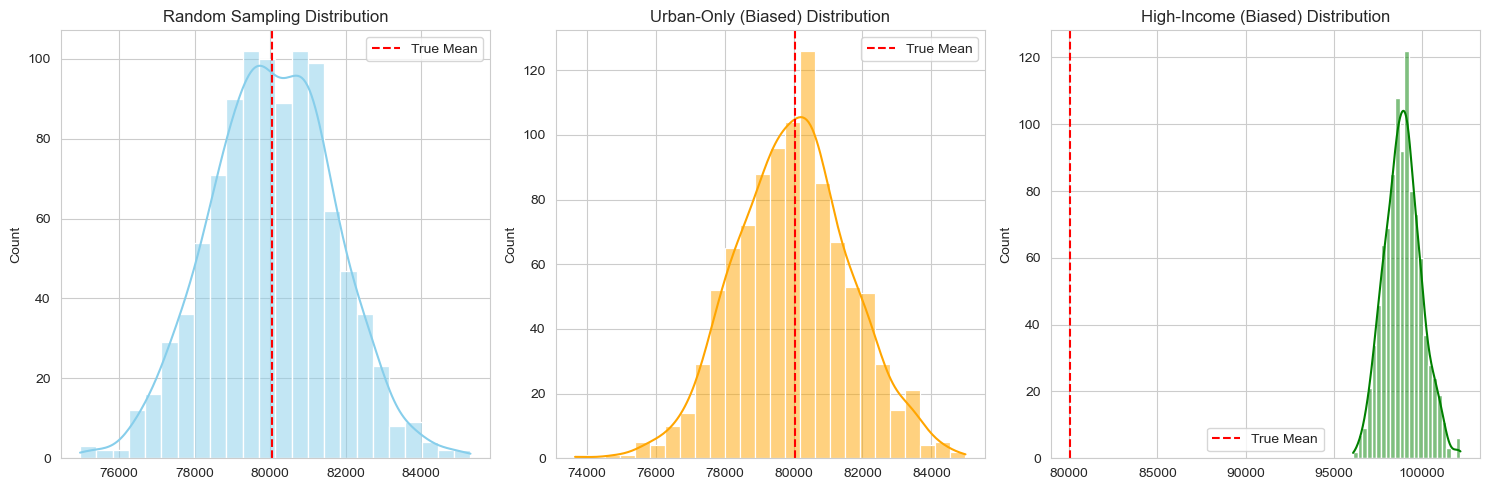

In [7]:
random_means = []
urban_means = []
high_income_means = []
income_median = df_pop['income'].median()
for _ in range(1000):
    random_means.append(df_pop['income'].sample(200).mean())
    urban_means.append(df_pop[df_pop['region'] == 'Urban']['income'].sample(200).mean())
    high_income_means.append(df_pop[df_pop['income'] > income_median]['income'].sample(200).mean())

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(random_means, color="skyblue", kde=True)
plt.axvline(df_pop['income'].mean(), color='red', linestyle='--', label='True Mean')
plt.title("Random Sampling Distribution")
plt.legend()

plt.subplot(1, 3, 2)
sns.histplot(urban_means, color="orange", kde=True)
plt.axvline(df_pop['income'].mean(), color='red', linestyle='--', label='True Mean')
plt.title("Urban-Only (Biased) Distribution")
plt.legend()

plt.subplot(1, 3, 3)
sns.histplot(high_income_means, color="green", kde=True)
plt.axvline(df_pop['income'].mean(), color='red', linestyle='--', label='True Mean')
plt.title("High-Income (Biased) Distribution")
plt.legend()

plt.tight_layout()
plt.show()

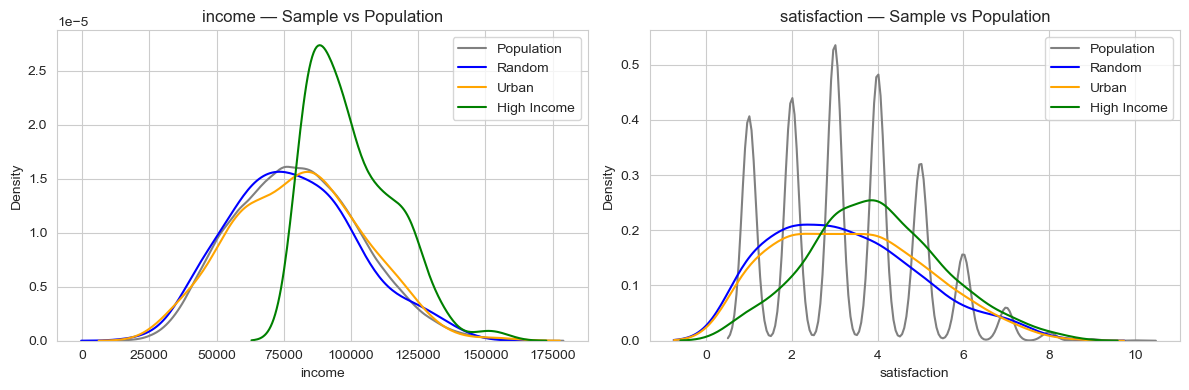

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['income', 'satisfaction']):
    sns.kdeplot(df_pop[col], ax=ax, label='Population', color='gray')
    sns.kdeplot(random_sample[col], ax=ax, label='Random', color='blue')
    sns.kdeplot(urban_sample[col], ax=ax, label='Urban', color='orange')
    sns.kdeplot(high_income_sample[col], ax=ax, label='High Income', color='green')
    ax.set_title(f'{col} — Sample vs Population')
    ax.legend()
plt.tight_layout()
plt.show()

The High-Income strategy produces a very biased estimate. We can see this in the third (green) histogram.The Red Line is the "True Mean" (80,000). The Random Sampling (blue) and Urban-Only (orange) histograms are close to the red line. But the High-Income (green) histogram is very far away from the red line. It shows a mean near 100,000. This means our sample is not representing the whole population correctly because we only picked rich people.